In [ ]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
import numpy as np
from typing import List, Tuple, Dict, Any
from Scripts.detection import extract_regions_with_detector
from Scripts.configs import DetectorConfig, ScriptOptions
import os
import json
from pathlib import Path


def load_detector_from_config(config_path: str, detector_name: str = None) -> List[DetectorConfig]:
    """
    Загружает конфигурацию детекторов из файла

    Args:
        config_path (str): Путь к JSON файлу с конфигурацией
        detector_name (str, optional): Имя конкретного детектора для загрузки

    Returns:
        List[DetectorConfig]: Список конфигураций детекторов
    """
    if not os.path.exists(config_path):
        print(f"Файл конфигурации детекторов не найден: {config_path}")
        return []

    try:
        with open(config_path, 'r', encoding='utf-8') as f:
            config_data = json.load(f)
    except json.JSONDecodeError as e:
        print(f"Ошибка в формате конфигурационного файла: {e}")
        return []

    detectors = []
    for item in config_data:
        if detector_name and item["name"] != detector_name:
            continue

        try:
            detector = DetectorConfig(
                name=item["name"],
                model_path=item["model_path"],
                confidence=item.get("confidence", 0.25),
                classes=item.get("classes", [0]),
                remove_tags_from_full=item.get("remove_tags_from_full", []),
                remove_tags_from_region=item.get("remove_tags_from_region", []),
                add_tags_to_region=item.get("add_tags_to_region", {}),
                exclude_from_region=item.get("exclude_from_region", []),
                region_gen_threshold=item.get("region_gen_threshold"),
                region_char_threshold=item.get("region_char_threshold"),
                use_min_side=item.get("use_min_side", False)
            )
            detectors.append(detector)
        except KeyError as e:
            print(f"Ошибка в конфигурации детектора: отсутствует обязательное поле {e}")
        except Exception as e:
            print(f"Ошибка обработки конфигурации детектора: {e}")

    return detectors


def test_detector_visualization(image_path: str, detector_config: DetectorConfig, options: ScriptOptions = None):
    """
    Тестирует функцию extract_regions_with_detector и визуализирует результаты

    Args:
        image_path (str): Путь к изображению
        detector_config (DetectorConfig): Конфигурация детектора
        options (ScriptOptions, optional): Опции скрипта
    """
    # Определяем путь к модели
    if options and options.yolo_model_dir:
        model_path = Path(options.yolo_model_dir) / detector_config.model_path
    else:
        model_path = Path("./models/yolo") / detector_config.model_path

    # Загружаем модель YOLO
    try:
        model = YOLO(str(model_path))
        print(f"Модель {model_path} успешно загружена")
    except Exception as e:
        print(f"Ошибка загрузки модели {model_path}: {e}")
        return None

    print(f"Применяем детектор: {detector_config.name}")
    print(f"Порог уверенности: {detector_config.confidence}")
    print(f"Классы для обнаружения: {detector_config.classes}")
    print(f"Использовать минимальную сторону: {detector_config.use_min_side}")

    # Загружаем изображение для проверки существования
    try:
        img = Image.open(image_path)
        print(f"Изображение {image_path} успешно загружено (размер: {img.size[0]}x{img.size[1]})")
    except Exception as e:
        print(f"Ошибка загрузки изображения {image_path}: {e}")
        return None

    # Получаем регионы
    regions = extract_regions_with_detector(img, model, detector_config)
    print(f"Обнаружено объектов: {len(regions)}")

    # Загружаем изображение для визуализации
    img_array = np.array(img)

    # Создаем фигуру для отображения
    n_regions = len(regions)
    if n_regions == 0:
        print("Не обнаружено ни одного объекта!")
        return None

    # Определим количество строк и столбцов для отображения всех регионов
    n_cols = min(3, n_regions)  # Максимум 3 столбца для регионов
    n_rows = (n_regions + n_cols - 1) // n_cols + 1  # +1 для исходного изображения

    fig = plt.figure(figsize=(15, 5 * n_rows))

    # Отображаем исходное изображение со всеми боксами
    ax_main = plt.subplot2grid((n_rows, n_cols), (0, 0), colspan=n_cols)
    ax_main.imshow(img_array)
    ax_main.set_title(f'Исходное изображение с объектами ({detector_config.name})')

    # Рисуем оригинальные боксы (прямоугольники) красным цветом
    for region in regions:
        orig_box = region['bbox']
        rect = patches.Rectangle(
            (orig_box[0], orig_box[1]),
            orig_box[2] - orig_box[0],
            orig_box[3] - orig_box[1],
            linewidth=2,
            edgecolor='r',
            facecolor='none',
            label='Оригинальный бокс'
        )
        ax_main.add_patch(rect)

        # Добавляем метки с размерами
        width = orig_box[2] - orig_box[0]
        height = orig_box[3] - orig_box[1]
        ax_main.text(
            orig_box[0],
            orig_box[1] - 5,
            f'Размер: {width:.1f}x{height:.1f}',
            color='red',
            fontsize=8
        )

    # Добавляем легенду
    handles = [
        patches.Patch(edgecolor='r', facecolor='none', label='Оригинальный бокс')
    ]
    ax_main.legend(handles=handles, loc='upper right')

    ax_main.set_axis_off()

    # Отображаем каждый вырезанный регион
    for i, region in enumerate(regions):
        # Корректный способ расчета строки и столбца
        row = 1 + (i // n_cols)  # +1 потому что первая строка занята исходным изображением
        col = i % n_cols

        ax_region = plt.subplot2grid((n_rows, n_cols), (row, col))
        ax_region.imshow(region['region'])

        # Размеры оригинального бокса
        orig_box = region['bbox']
        orig_width = orig_box[2] - orig_box[0]
        orig_height = orig_box[3] - orig_box[1]

        # Отношение сторон для оригинального бокса
        aspect_ratio = orig_width / orig_height if orig_height > 0 else 0

        ax_region.set_title(
            f'Регион {i+1}\n'
            f'Размер: {orig_width:.1f}x{orig_height:.1f} (AR: {aspect_ratio:.2f})\n'
            f'Уверенность: {region["confidence"]:.2f}'
        )
        ax_region.set_axis_off()

    plt.tight_layout()
    plt.show()

    return regions


def main_test(image_path: str, config_path: str, detector_name: str = None):
    """
    Основная функция для тестирования.

    Args:
        image_path (str): Путь к изображению
        config_path (str): Путь к конфигурационному файлу
        detector_name (str, optional): Имя конкретного детектора
    """
    # Загружаем настройки скрипта (можно создать дефолтные)
    options = ScriptOptions(
        ImageFolder=Path("."),
        yolo_model_dir=Path("./models/yolo/")
    )

    # Загружаем детекторы из конфига
    detectors = load_detector_from_config(config_path, detector_name)

    if not detectors:
        if detector_name:
            print(f"Детектор '{detector_name}' не найден в конфигурации")
        else:
            print("Не найдено ни одного детектора в конфигурации")
        return

    # Тестируем каждый детектор
    for detector in detectors:
        print(f"\n--- Тестирование детектора '{detector.name}' ---")
        test_detector_visualization(image_path, detector, options)

# Пример использования:
# main_test("path/to/image.jpg", "detectors.json", "face_detector")


--- Тестирование детектора 'person_detector' ---
Модель models\yolo\person_yolov8s-seg.pt успешно загружена
Применяем детектор: person_detector
Порог уверенности: 0.4
Классы для обнаружения: [0]
Использовать минимальную сторону: False
Изображение Tests\abc\GdjyZ8t.png успешно загружено (размер: 1920x1080)

0: 384x640 2 persons, 46.5ms
Speed: 3.2ms preprocess, 46.5ms inference, 5.9ms postprocess per image at shape (1, 3, 384, 640)
Обнаружено объектов: 2


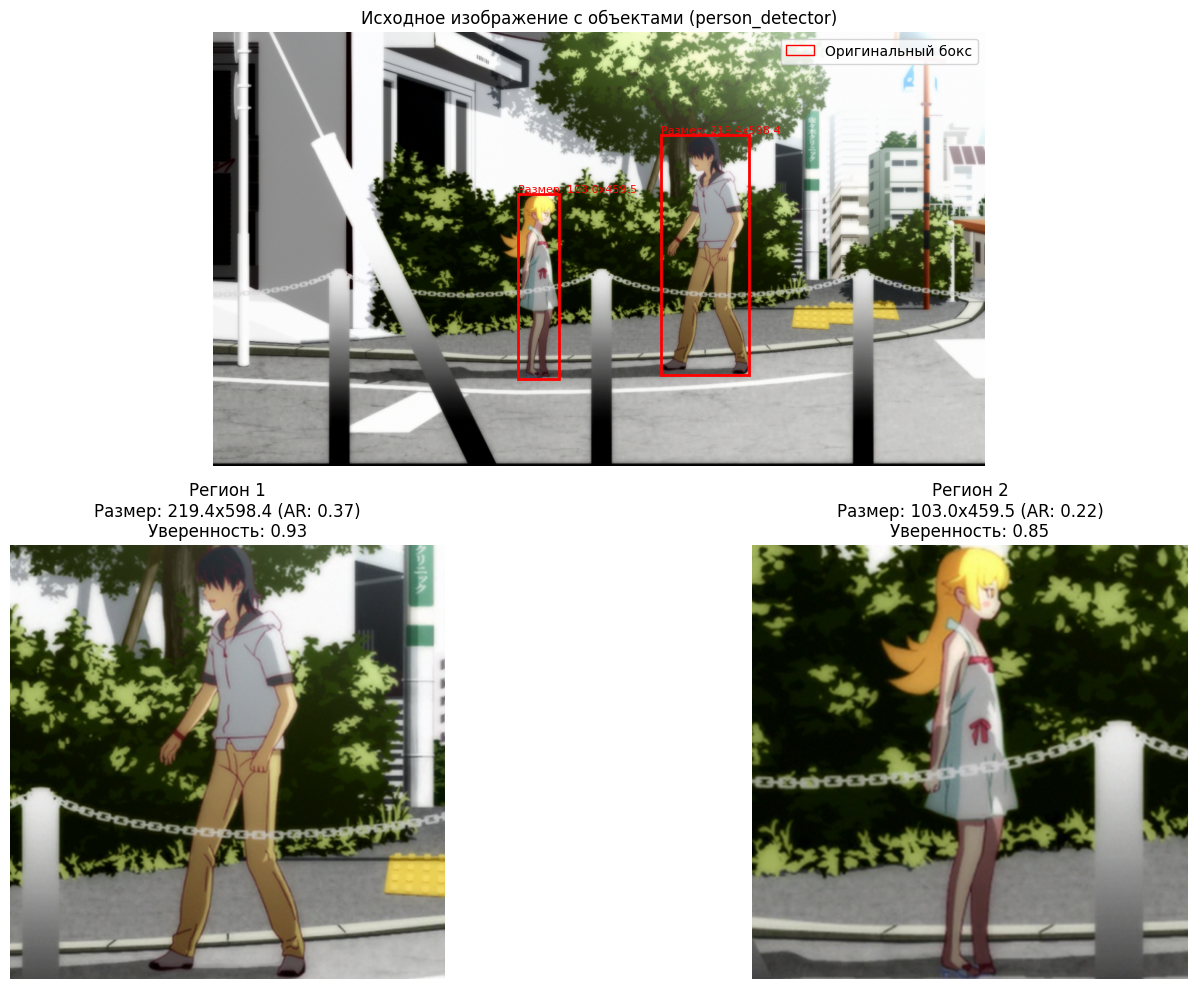


--- Тестирование детектора 'face_detector' ---
Модель models\yolo\face_yolov9c.pt успешно загружена
Применяем детектор: face_detector
Порог уверенности: 0.4
Классы для обнаружения: [0]
Использовать минимальную сторону: False
Изображение Tests\abc\GdjyZ8t.png успешно загружено (размер: 1920x1080)

0: 384x640 2 faces, 33.6ms
Speed: 3.6ms preprocess, 33.6ms inference, 2.8ms postprocess per image at shape (1, 3, 384, 640)
Обнаружено объектов: 2


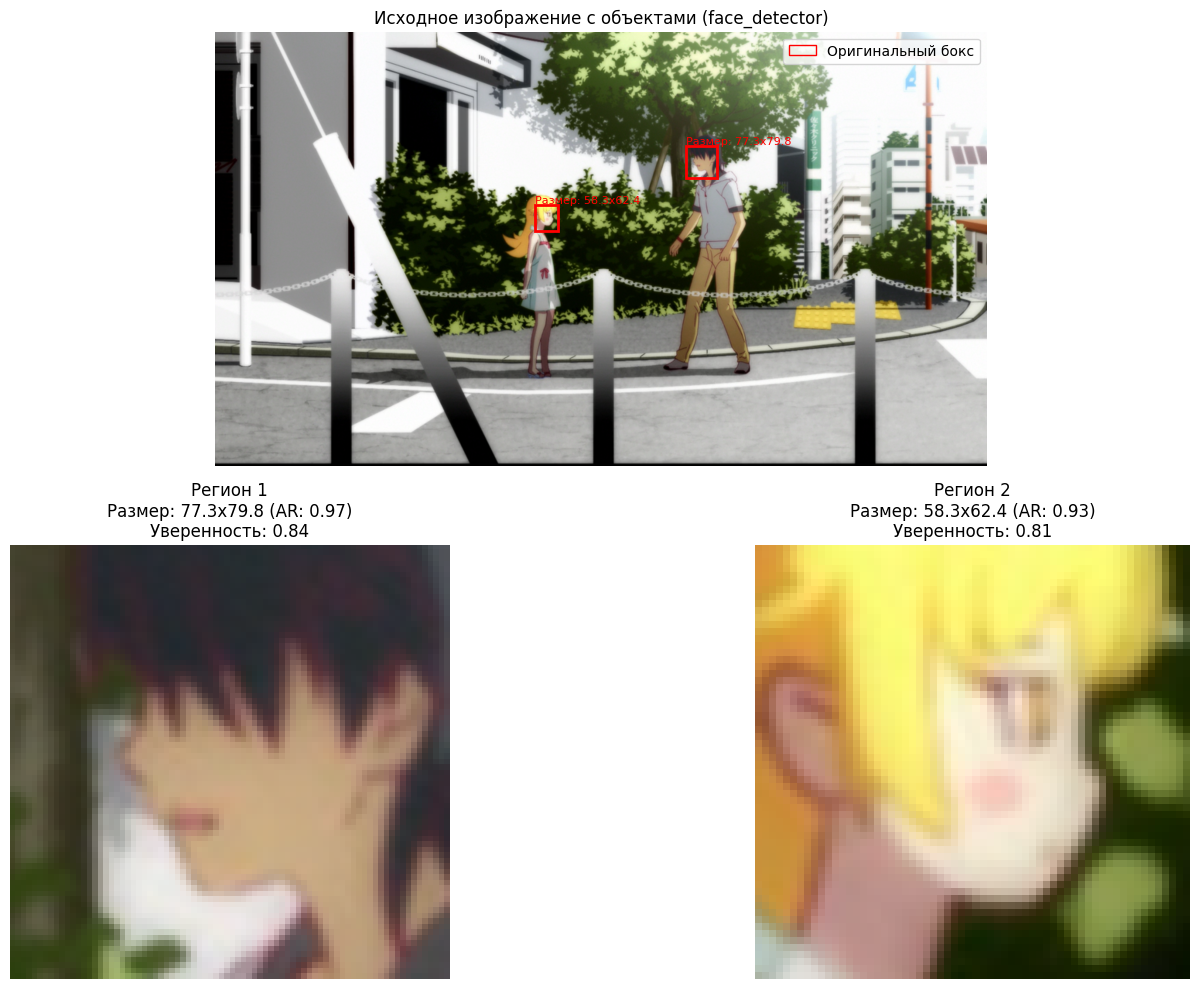

In [ ]:
main_test(r"Tests\abc\GdjyZ8t.png", "detectors.json", None)